In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mat73
import os

In [14]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
cfg = mat73.loadmat(os.path.join(baseDir, lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre)
t = np.concatenate((t_cue, t_pert))

In [54]:
monkey = 'Pert'
rec = 13
roi = 'S1'
lfp = np.load(os.path.join(baseDir, lfpDir, 'Pert', f'lfp_aligned.{roi}-{rec}.npy') )
lfp_avg = lfp.mean(axis=-1)

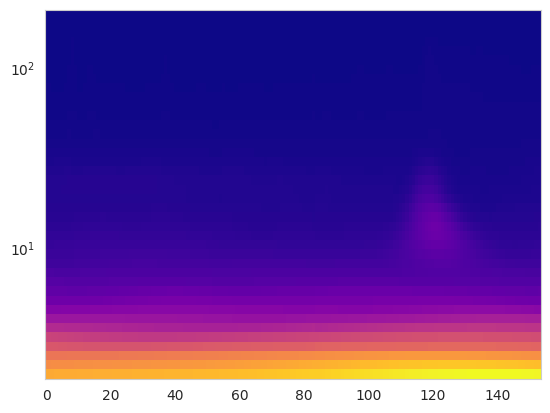

In [55]:
fig, ax = plt.subplots()
ax.pcolormesh(t, foi, np.delete(lfp, [4, 7, 8], axis=1).mean(axis=(1, -1)).T, cmap='plasma')
ax.set_yscale('log')

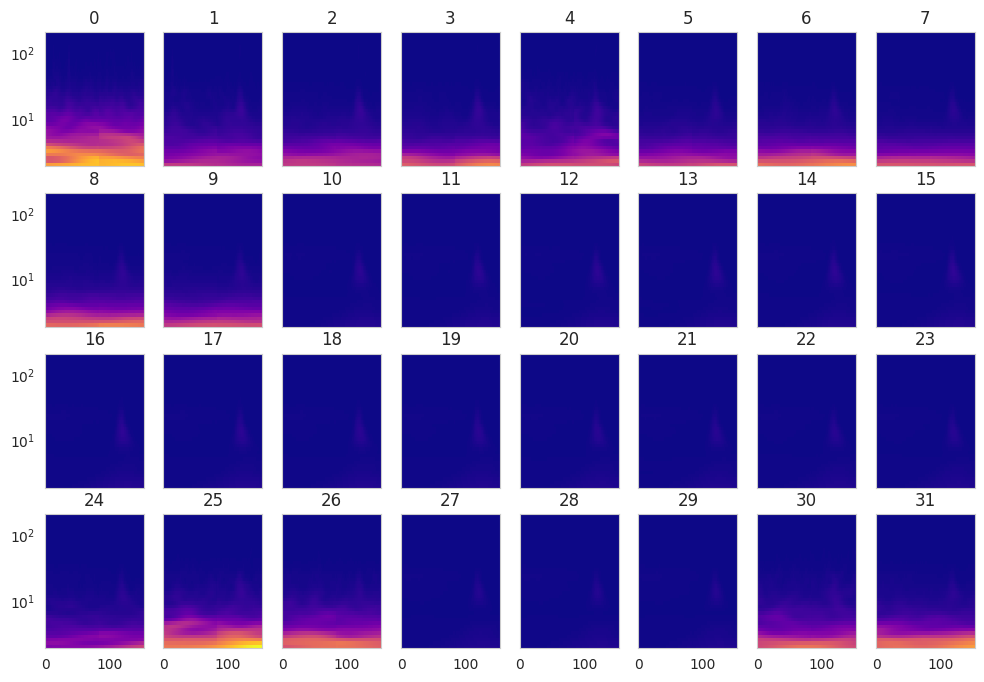

In [56]:
fig, axs = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(12, 8))
for ch in range(lfp_avg.shape[1]):
    ax = axs[ch // 8, ch % 8]
    ax.pcolormesh(t, foi, lfp_avg[:, ch].T, cmap='plasma', vmin=lfp_avg.min(), vmax=lfp_avg.max())
    ax.set_title(ch)
    ax.set_yscale('log')

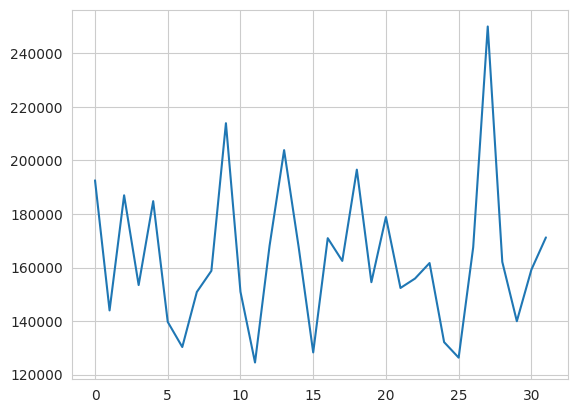

In [57]:
X = lfp
time, chan, freq, trial = X.shape
Xr = X.reshape(-1, chan)
err = Xr - Xr.mean(axis=0, keepdims=True)
cov = np.cov(err, rowvar=False)
plt.plot(np.diag(cov))

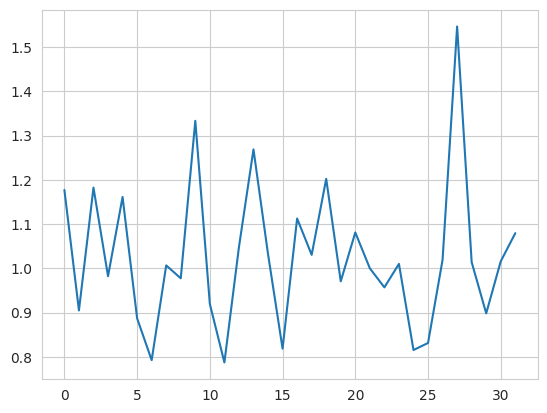

In [58]:
lfp_prewhitened = lfp / np.sqrt(np.diag(cov))[None, :, None, None]
X = lfp_prewhitened
time, chan, freq, trial = X.shape
Xr = X.reshape(-1, chan)
err = Xr - Xr.mean(axis=0, keepdims=True)
cov = np.cov(err, rowvar=False)
plt.plot(np.diag(cov))

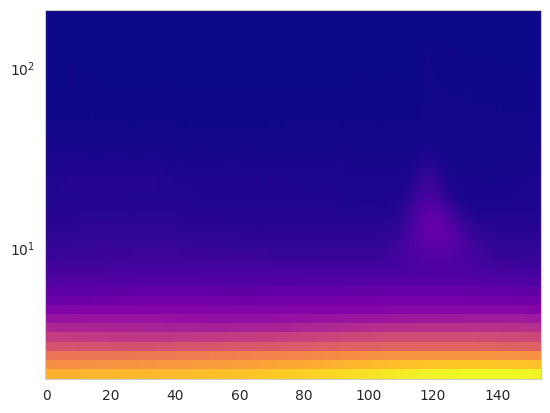

In [59]:
fig, ax = plt.subplots()
ax.pcolormesh(t, foi, lfp_prewhitened.mean(axis=(1, -1)).T, cmap='plasma')
ax.set_yscale('log')

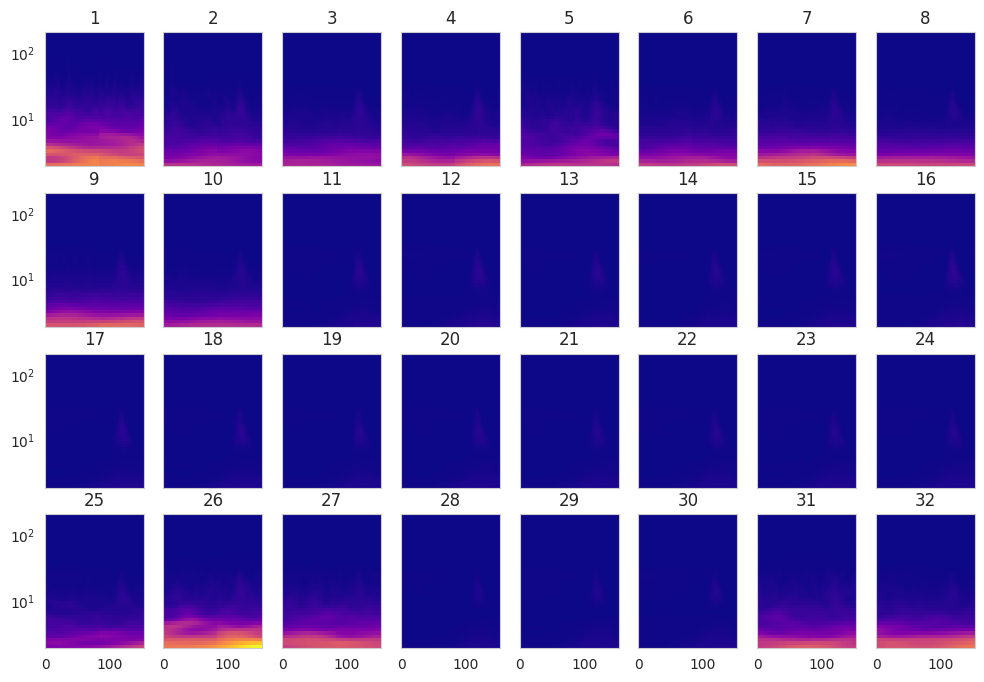

In [60]:
lfp_avg = lfp_prewhitened.mean(axis=-1)
fig, axs = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(12, 8))
for ch in range(lfp_avg.shape[1]):
    ax = axs[ch // 8, ch % 8]
    ax.pcolormesh(t, foi, lfp_avg[:, ch].T, cmap='plasma', vmin=lfp_avg.min(), vmax=lfp_avg.max())
    ax.set_title(ch+1)
    ax.set_yscale('log')

In [61]:
X = lfp
Xw = np.empty_like(X)
for f in range(freq):
    # Collapse time × trial
    Xf = X[:, :, f, :].reshape(-1, chan)
    cov = np.cov(Xf, rowvar=False)
    eps = 1e-6 * np.trace(cov) / chan
    cov_reg = cov + eps * np.eye(chan)
    w, U = np.linalg.eigh(cov_reg)
    W = (U * (1.0 / np.sqrt(np.maximum(w, 0)))) @ U.T

    Xw[:, :, f, :] = Xf.reshape(time, chan, trial) / np.sqrt(np.diag(cov))[None, :, None] #(Xf @ W.T).reshape(time, chan, trial)


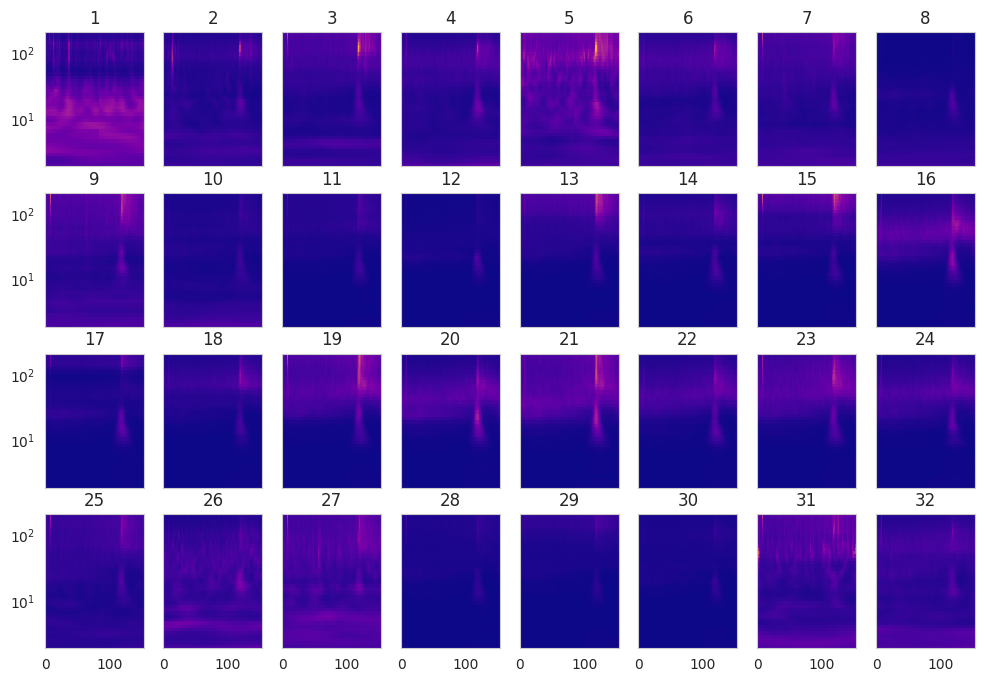

In [62]:
lfp_avg = Xw.mean(axis=-1)
fig, axs = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(12, 8))
for ch in range(lfp_avg.shape[1]):
    ax = axs[ch // 8, ch % 8]
    ax.pcolormesh(t, foi, lfp_avg[:, ch].T, cmap='plasma', vmin=lfp_avg.min(), vmax=lfp_avg.max())
    ax.set_title(ch+1)
    ax.set_yscale('log')